LIBRARIES

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

INPUTS

In [2]:
IMG_HEIGHT =224
IMG_WIDTH =224
IMG_CHANNELS =3
CLASS_NAMES = ["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [3]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\train",
    labels = 'inferred',
    label_mode = 'int',
    image_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = 16
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\val",
    labels = 'inferred',
    label_mode = 'int',
    image_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = 16
)

normalize = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalize(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalize(x), y))

Found 3000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


NETWORK ARCHITECTURE

In [4]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    include_top=False,
    weights = 'imagenet'    
)

base_model.trainable = True
model = keras.Sequential([
    base_model,

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])

optimizer = tf.keras.optimizers.Adam()

base_learning_rate = 1e-5
head_learning_rate = 1e-4

for layer in model.layers[0].layers:
    layer.trainable=True
    layer._learning_rate = base_learning_rate
for layer in model.layers[1:]:
    layer._learning_rate = head_learning_rate

model.compile(
    optimizer = optimizer,
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics =['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,509 (8.66 MB)

 Trainable params: 2,232,837 (8.52 MB)

 Non-trainable params: 36,672 (143.25 KB)

TRAINING

In [5]:
EPOCHS =10
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 163s 771ms/step - accuracy: 0.7267 - loss: 0.9443 - val_accuracy: 0.2340 - val_loss: 19.7945
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 145s 770ms/step - accuracy: 0.8530 - loss: 0.4357 - val_accuracy: 0.4640 - val_loss: 7.3467
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 144s 766ms/step - accuracy: 0.8773 - loss: 0.3685 - val_accuracy: 0.3960 - val_loss: 8.5673
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 144s 765ms/step - accuracy: 0.8903 - loss: 0.3374 - val_accuracy: 0.3490 - val_loss: 8.6275
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 143s 757ms/step - accuracy: 0.9173 - loss: 0.2540 - val_accuracy: 0.6740 - val_loss: 2.1901
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 142s 756ms/step - accuracy: 0.9163 - loss: 0.2607 - val_accuracy: 0.5950 - val_loss: 5.2184
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 141s 750ms/step - accuracy: 0.9063 - loss: 0.3080 - val_accuracy: 0.6480 - val_loss: 3.1333
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 142s 755ms/step - accuracy: 0.9307 

PLOTTING

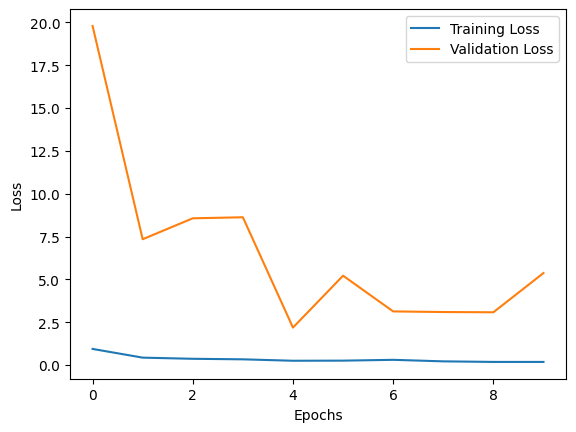

In [7]:
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

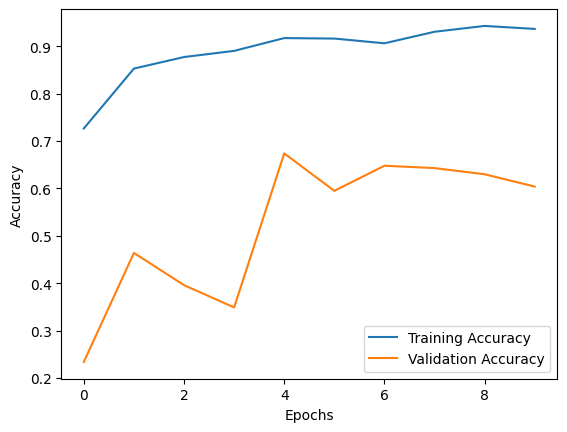

In [8]:
plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()